# ISLES'22 - Parca 7: Degerlendirme

**Bagimsiz notebook.** `isles_egitim.ipynb`'den yalniz gereken tanimlar alindi; egitim
hucresi yok, dolayisiyla yanlislikla model yeniden egitme riski de yok.

Hucreler egitim notebook'undan programli olarak kopyalandi - elle tasinmadi, ikisi ayrisamaz.

| Bolum | Ne |
|---|---|
| Hazirlik | ortam, metrikler, model fabrikasi, veri hatti |
| 7.1 | Esik taramasi (**val** uzerinde) |
| 7.2 | Kucuk bilesen eleme (**val** uzerinde) |
| 7.3 | Secimin test'e uygulanmasi (tek sefer) |
| 7.4 | Bootstrap CI + Holm |
| 7.5 | Lezyon F1 tanim dogrulamasi + `panoptica` |

**Bastan sona calistir** (Run All). Toplam ~7 dk; en uzun adim pip kurulumu ve olasilik
haritalarinin uretilmesi.

> Esik ve bilesen esigi **yalniz val'de** taraniyor, test'e tek sefer uygulaniyor. Test
> uzerinde taramak 50 vakaya uydurmak olurdu ve raporlanan sayilari iyimser yapardi.

## Hazirlik

Egitim notebook'undaki tanimlarin aynisi: ortam, 3B metrikler,
model fabrikasi ve veri hatti.


In [1]:
import os, json, time, shutil, math, random
from pathlib import Path

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'


def drive_bagla(nokta='/content/drive'):
    '''Colab'da Drive'i baglar. Onceki oturum koptuysa mount noktasi bayat dosyalarla
    dolu kalir ve duz mount() 'Mountpoint must not already contain files' hatasi verir;
    o durumda force_remount denenir.'''
    if ORTAM != 'colab':
        return None
    from google.colab import drive
    if os.path.ismount(nokta):
        print('Drive zaten bagli:', nokta)
        return nokta
    try:
        drive.mount(nokta)
    except ValueError as e:
        print('duz mount basarisiz (%s) -> force_remount' % e)
        drive.mount(nokta, force_remount=True)
    return nokta


drive_bagla()

PROJE = '/content/drive/MyDrive/iskemik_inme' if ORTAM == 'colab' else str(Path.cwd())
HAZIR = os.path.join(PROJE, 'hazir')
YEREL = '/content/outputs' if ORTAM == 'colab' else os.path.join(PROJE, 'outputs')
os.makedirs(YEREL, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

CFG = json.load(open(os.path.join(HAZIR, 'config.json')))
SPLIT = json.load(open(os.path.join(PROJE, 'split.json')))
EVAL_CASES = json.load(open(os.path.join(PROJE, 'eval_cases.json')))
MAN = pd.read_csv(os.path.join(HAZIR, 'manifest.csv'))

SPACING = tuple(CFG['hedef_spacing'])
VOXEL_ML = float(np.prod(SPACING)) / 1000.0

print('PROJE:', PROJE)
print('girdi:', CFG['girdi_H'], 'x', CFG['girdi_W'], '| spacing:', SPACING, '| voxel:', VOXEL_ML, 'mL')
print('split:', {k: len(v) for k, v in SPLIT.items()})
print('eval_cases:', EVAL_CASES)

Drive zaten bagli: /content/drive
PROJE: /content/drive/MyDrive/iskemik_inme
girdi: 96 x 128 | spacing: (2.0, 2.0, 2.0) | voxel: 0.008 mL
split: {'train': 161, 'val': 39, 'test': 50}
eval_cases: ['sub-strokecase0016', 'sub-strokecase0158', 'sub-strokecase0029', 'sub-strokecase0192', 'sub-strokecase0031']


In [2]:
import torch

CKPT_ZORUNLU = ['model', 'optimizer', 'epoch', 'best_dice']


def save_checkpoint(yol, model, optimizer, scheduler, scaler, epoch, best_dice,
                    epochs_without_improve, ekstra=None):
    durum = {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict() if scheduler is not None else None,
        'scaler': scaler.state_dict() if scaler is not None else None,
        'epoch': int(epoch),
        'best_dice': float(best_dice),
        'epochs_without_improve': int(epochs_without_improve),
        'rng_torch': torch.get_rng_state(),
        'rng_numpy': np.random.get_state(),
        'rng_python': random.getstate(),
        'ekstra': ekstra or {},
    }
    os.makedirs(os.path.dirname(yol), exist_ok=True)
    gecici = yol + '.tmp'
    torch.save(durum, gecici)      # once gecici dosya: yazma sirasinda oturum koparsa
    os.replace(gecici, yol)        # eski checkpoint bozulmasin
    return yol


def find_resumable_checkpoint(kok):
    '''last.pt varsa ve tam ise dondurur. Eksikse SESSIZ GECMEZ, hata verir.'''
    yol = os.path.join(kok, 'checkpoints', 'last.pt')
    if not os.path.exists(yol):
        return None, None
    durum = torch.load(yol, map_location='cpu', weights_only=False)
    eksik = [k for k in CKPT_ZORUNLU if k not in durum or durum[k] is None]
    if eksik:
        raise RuntimeError(f'{yol} stripped checkpoint - eksik anahtar: {eksik}. '
                           f'Resume edilemez; RESUME=False ile bastan baslatin.')
    return yol, durum


def restore_checkpoint(durum, model, optimizer=None, scheduler=None, scaler=None, rng=True):
    model.load_state_dict(durum['model'])
    if optimizer is not None:
        optimizer.load_state_dict(durum['optimizer'])
    if scheduler is not None and durum.get('scheduler') is not None:
        scheduler.load_state_dict(durum['scheduler'])
    if scaler is not None and durum.get('scaler') is not None:
        scaler.load_state_dict(durum['scaler'])
    if rng:
        torch.set_rng_state(durum['rng_torch'].cpu() if torch.is_tensor(durum['rng_torch'])
                            else durum['rng_torch'])
        np.random.set_state(durum['rng_numpy'])
        random.setstate(durum['rng_python'])
    return durum['epoch'], durum['best_dice'], durum.get('epochs_without_improve', 0)


def mirror_to_local(model_key):
    '''Drive'daki model klasorunu yerel diske kopyalar (Drive I/O yavas, rapor uretimi hizli olsun).'''
    kaynak, hedef = os.path.join(PROJE, model_key), os.path.join(YEREL, model_key)
    if os.path.isdir(kaynak):
        shutil.copytree(kaynak, hedef, dirs_exist_ok=True)
    return hedef

In [3]:
LEZYON_IOU_ESIK = 0.1     # bir GT lezyonu "yakalandi" sayilmasi icin gereken IoU
BAGLANTI = np.ones((3, 3, 3))   # 26-komsuluk


def _yuzey(m):
    return m & ~ndimage.binary_erosion(m, np.ones((3, 3, 3)))


def hd95(tahmin, gt, spacing=SPACING):
    '''Simetrik %95 Hausdorff, mm. Bir taraf bos ise NaN.

    Hesap birlesim bbox'ina kirpilip yapiliyor: EDT'nin kaynagi olan yuzey voxelleri
    tamamen bu kutunun icinde oldugu icin mesafeler BIREBIR ayni cikiyor (yerelde dort
    senaryoda fark 0.0, hizlanma 2.9-4.2x). 1 voxel sifir dolgu, erozyonun kutu kenarini
    sahte yuzey saymasini engelliyor.'''
    if not tahmin.any() or not gt.any():
        return 0.0 if (not tahmin.any() and not gt.any()) else float('nan')
    idx = np.where(tahmin | gt)
    dilim = tuple(slice(max(int(i.min()) - 1, 0), int(i.max()) + 2) for i in idx)
    t = np.pad(tahmin[dilim], 1)
    g = np.pad(gt[dilim], 1)
    yt, yg = _yuzey(t), _yuzey(g)
    dt_g = ndimage.distance_transform_edt(~yg, sampling=spacing)
    dt_t = ndimage.distance_transform_edt(~yt, sampling=spacing)
    return float(max(np.percentile(dt_g[yt], 95), np.percentile(dt_t[yg], 95)))


def lezyon_metrikleri(tahmin, gt, iou_esik=LEZYON_IOU_ESIK):
    '''Bagli bilesen eslestirme. Bir GT bileseni, IoU >= esik olan bir tahmin bileseniyle
    eslesirse TP. Eslesmemis GT -> FN, eslesmemis tahmin -> FP.'''
    et_g, n_g = ndimage.label(gt, BAGLANTI)
    et_t, n_t = ndimage.label(tahmin, BAGLANTI)
    if n_g == 0 and n_t == 0:
        return dict(lezyon_f1=1.0, lezyon_tp=0, lezyon_fp=0, lezyon_fn=0,
                    lezyon_sayi_gt=0, lezyon_sayi_tahmin=0, lezyon_sayi_fark=0)

    eslesen_t = set()
    tp = 0
    for i in range(1, n_g + 1):
        gi = et_g == i
        # bu GT bileseniyle ortusen tahmin bilesenleri
        adaylar = np.unique(et_t[gi])
        adaylar = adaylar[adaylar > 0]
        en_iyi = 0.0
        en_iyi_j = None
        for j in adaylar:
            tj = et_t == j
            kesisim = np.logical_and(gi, tj).sum()
            birlesim = np.logical_or(gi, tj).sum()
            iou = kesisim / birlesim if birlesim else 0.0
            if iou > en_iyi:
                en_iyi, en_iyi_j = iou, j
        if en_iyi >= iou_esik and en_iyi_j is not None:
            tp += 1
            eslesen_t.add(int(en_iyi_j))

    fn = n_g - tp
    fp = n_t - len(eslesen_t)
    payda = 2 * tp + fp + fn
    return dict(lezyon_f1=(2 * tp / payda) if payda else 1.0,
                lezyon_tp=tp, lezyon_fp=fp, lezyon_fn=fn,
                lezyon_sayi_gt=n_g, lezyon_sayi_tahmin=n_t, lezyon_sayi_fark=abs(n_t - n_g))


def vaka_metrikleri(tahmin, gt, spacing=SPACING, ayrintili=True):
    '''Tek vakanin butun metrikleri. tahmin/gt: bool 3B dizi, ayni sekil.'''
    tahmin = np.asarray(tahmin, dtype=bool)
    gt = np.asarray(gt, dtype=bool)
    assert tahmin.shape == gt.shape, 'sekil uyusmuyor'

    tp = float(np.logical_and(tahmin, gt).sum())
    fp = float(np.logical_and(tahmin, ~gt).sum())
    fn = float(np.logical_and(~tahmin, gt).sum())
    bos_gt, bos_tahmin = gt.sum() == 0, tahmin.sum() == 0

    if bos_gt and bos_tahmin:
        dice = iou = precision = 1.0
        recall = float('nan')
    else:
        dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0
        iou = tp / (tp + fp + fn) if (tp + fp + fn) else 0.0
        precision = tp / (tp + fp) if (tp + fp) else (1.0 if bos_gt else 0.0)
        recall = tp / (tp + fn) if (tp + fn) else float('nan')

    voxel_ml = float(np.prod(spacing)) / 1000.0
    out = dict(dice=dice, iou=iou, precision=precision, recall=recall, f1=dice,
               hacim_gt_ml=float(gt.sum()) * voxel_ml,
               hacim_tahmin_ml=float(tahmin.sum()) * voxel_ml)
    out['avd_ml'] = abs(out['hacim_tahmin_ml'] - out['hacim_gt_ml'])
    if ayrintili:
        out['hd95'] = hd95(tahmin, gt, spacing)
        out.update(lezyon_metrikleri(tahmin, gt))
    return out


def topla(metrik_listesi):
    '''Vaka metriklerini ortalar. NaN'lar disarida birakilir (nanmean).'''
    df = pd.DataFrame(metrik_listesi)
    return {k: float(np.nanmean(df[k])) for k in df.columns if df[k].dtype != object}

In [4]:
os.system('pip -q install segmentation-models-pytorch albumentations')
import segmentation_models_pytorch as smp
import albumentations as A
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

CIHAZ = 'cuda' if torch.cuda.is_available() else 'cpu'
print('smp:', smp.__version__, '| albumentations:', A.__version__)
print('cihaz:', CIHAZ, torch.cuda.get_device_name(0) if CIHAZ == 'cuda' else '')

smp: 0.5.0 | albumentations: 2.0.8
cihaz: cuda Tesla T4


In [5]:
MODEL_CONFIGS = {
    # --- 5 mimari ---
    'unet_r34_2d': dict(mimari='unet', encoder='resnet34', k=0, batch=32,
                        lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
    'unet_r34_25d': dict(mimari='unet', encoder='resnet34', k=2, batch=32,
                         lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
    'segformer_b0': dict(mimari='segformer', encoder='nvidia/mit-b0', k=2, batch=32,
                         lr_enc=1e-4, lr_dec=1e-4, loss='dice_bce'),
    'unet_mbv3': dict(mimari='unet', encoder='timm-mobilenetv3_large_100', k=2, batch=32,
                      lr_enc=1e-4, lr_dec=5e-4, loss='dice_bce'),
    # Tam hacim - patch degil. Kirpilmis hacimler 96x128x<=96'ya sigiyor (Parca 2 olcumu),
    # dolayisiyla patch'lemeye ve kaydirmali pencere cikarimina gerek yok. Vaka basina
    # tek ileri gecis, gercek zamanli hedefe de bu uyuyor.
    'unet3d': dict(mimari='unet3d', encoder=None, k=None, batch=2,
                   lr_enc=3e-4, lr_dec=3e-4, loss='dice_bce', tekrar=3),
    # --- ablasyonlar (Bolum 4) ---
    'A1_flair': dict(mimari='unet', encoder='resnet34', k=2, batch=32,
                     lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce', flair=True),
    # Yalniz bolge kaybi degisiyor (Dice -> focal-Tversky); BCE terimi ve ornekleme orani
    # taban cizgisiyle ayni. Ilk tasarimda lezyon_orani da 0.7'ye cekiliyordu - iki degisken
    # birden degisince fark hangisinden geldigi ayrilamazdi.
    'A2_tversky': dict(mimari='unet', encoder='resnet34', k=2, batch=32,
                       lr_enc=5e-5, lr_dec=2.5e-4, loss='focal_tversky'),
    'A3_k1': dict(mimari='unet', encoder='resnet34', k=1, batch=32,
                  lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
    'A3_k3': dict(mimari='unet', encoder='resnet34', k=3, batch=32,
                  lr_enc=5e-5, lr_dec=2.5e-4, loss='dice_bce'),
}

ORTAK = dict(
    max_epochs=70, patience=15, warmup_epochs=3, weight_decay=1e-4,
    plateau_factor=0.5, plateau_patience=3, min_lr=1e-7,
    grad_clip=1.0, amp=True, seed=42, tekrar=1,
    lezyon_orani=0.5,     # egitimde lezyonlu dilim orani (kalan bos dilimden)
    esik=0.5,             # val'de sabit; nihai esik Parca 7'de taranacak
    flair=False,
)

def konfig(model_key):
    if model_key not in MODEL_CONFIGS:
        raise KeyError(f'{model_key!r} tanimli degil. Gecerli anahtarlar: '
                       + ', '.join(MODEL_CONFIGS))
    c = dict(ORTAK)
    c.update(MODEL_CONFIGS[model_key])
    c['model_key'] = model_key
    # FLAIR eklenince o da 2k+1 dilimlik baglamla geliyor: 3 modalite x (2k+1).
    # Ilk surumde '+1' yazilmisti (tek FLAIR dilimi) - 2.5D ablasyonuyla karsilastirilabilir
    # olmasi icin ucu de ayni baglami almali.
    modalite = 3 if c['flair'] else 2
    c['kanal'] = 2 if c['k'] is None else modalite * (2 * c['k'] + 1)
    return c

for k in MODEL_CONFIGS:
    c = konfig(k)
    print(f"{k:15s} {c['mimari']:9s} k={str(c['k']):4s} kanal={c['kanal']:3d} "
          f"batch={c['batch']:3d} loss={c['loss']}")

unet_r34_2d     unet      k=0    kanal=  2 batch= 32 loss=dice_bce
unet_r34_25d    unet      k=2    kanal= 10 batch= 32 loss=dice_bce
segformer_b0    segformer k=2    kanal= 10 batch= 32 loss=dice_bce
unet_mbv3       unet      k=2    kanal= 10 batch= 32 loss=dice_bce
unet3d          unet3d    k=None kanal=  2 batch=  2 loss=dice_bce
A1_flair        unet      k=2    kanal= 15 batch= 32 loss=dice_bce
A2_tversky      unet      k=2    kanal= 10 batch= 32 loss=focal_tversky
A3_k1           unet      k=1    kanal=  6 batch= 32 loss=dice_bce
A3_k3           unet      k=3    kanal= 14 batch= 32 loss=dice_bce


In [6]:
H_HEDEF, W_HEDEF = CFG['girdi_H'], CFG['girdi_W']


def npy_yukle(vakalar, flair=False):
    d = {}
    for v in vakalar:
        kayit = dict(x=np.load(os.path.join(HAZIR, f'{v}_x.npy')),
                     y=np.load(os.path.join(HAZIR, f'{v}_y.npy')))
        if flair:
            fy = os.path.join(HAZIR, f'{v}_f.npy')
            if not os.path.exists(fy):
                raise FileNotFoundError(
                    f'{fy} yok. FLAIR onbellegi uretilmemis - once '
                    f'isles_veri_hazirlik.ipynb "Parca 2b - FLAIR hazirlama" bolumunu calistir.')
            kayit['x'] = np.concatenate([kayit['x'], np.load(fy)], axis=0)   # (3, h, w, d)
        d[v] = kayit
    return d


def dolgula(a, H=H_HEDEF, W=W_HEDEF):
    '''(.., h, w) -> (.., H, W) merkezden sifir dolgu. Tasarsa merkezden kirpar.

    Parca 2 olcumu: H max 87 <= 96, W max 101 <= 128, yani tasan vaka yok.
    Tasma olursa vaka_tahmin'deki dolgu-geri-alma matematigi bozulur - sessiz
    yanlis sonuc yerine burada gorunur olsun diye kirpma yolu uyari basiyor.'''
    h, w = a.shape[-2:]
    if h > H or w > W:
        print(f'UYARI: {h}x{w} hedefi ({H}x{W}) asiyor, merkezden kirpiliyor')
    ust, sol = (H - h) // 2, (W - w) // 2
    if h > H or w > W:
        y0, x0 = max((h - H) // 2, 0), max((w - W) // 2, 0)
        a = a[..., y0:y0 + min(h, H), x0:x0 + min(w, W)]
        h, w = a.shape[-2:]
        ust, sol = (H - h) // 2, (W - w) // 2
    pad = [(0, 0)] * (a.ndim - 2) + [(ust, H - h - ust), (sol, W - w - sol)]
    return np.pad(a, pad)


def augment_yap():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), rotate=(-10, 10), translate_percent=(-0.05, 0.05), p=0.5),
        A.ElasticTransform(alpha=20, sigma=6, p=0.15),
    ])


def worker_init(worker_id):
    '''torch yalniz kendi RNG'sini worker basina tohumluyor; numpy ve random tohumsuz kalip
    her worker'da ayni augmentasyon akisini uretiyor. Elle tohumlaniyor.'''
    tohum = torch.initial_seed() % 2**31
    np.random.seed(tohum + worker_id)
    random.seed(tohum + worker_id)


class DilimVeri(Dataset):
    '''2D / 2.5D dilim veri seti. k=0 tek dilim, k>0 icin 2k+1 komsu dilim kanal olarak yiginlanir.'''

    def __init__(self, vakalar, veri, k, egitim, lezyon_orani=0.5, seed=42):
        self.veri, self.k, self.egitim = veri, (k or 0), egitim
        self.lezyon_orani = lezyon_orani
        self.aug = augment_yap() if egitim else None
        self.rng = np.random.default_rng(seed)
        self.lezyonlu, self.bos = [], []
        for v in vakalar:
            y = veri[v]['y']
            lez = y.sum(axis=(0, 1)) > 0
            for z in range(y.shape[2]):
                (self.lezyonlu if lez[z] else self.bos).append((v, z))
        self.karistir()

    def karistir(self):
        if not self.egitim:
            self.indeks = self.lezyonlu + self.bos
            return
        n_lez = len(self.lezyonlu)
        n_bos = int(n_lez * (1 - self.lezyon_orani) / max(self.lezyon_orani, 1e-6))
        secilen = [self.bos[i] for i in self.rng.choice(len(self.bos), min(n_bos, len(self.bos)),
                                                        replace=False)] if self.bos else []
        self.indeks = self.lezyonlu + secilen
        self.rng.shuffle(self.indeks)

    def __len__(self):
        return len(self.indeks)

    def __getitem__(self, i):
        v, z = self.indeks[i]
        x, y = self.veri[v]['x'], self.veri[v]['y']
        D = x.shape[3]
        zs = np.clip(np.arange(z - self.k, z + self.k + 1), 0, D - 1)   # kenarda tekrarla
        img = x[:, :, :, zs].astype(np.float32)          # (M, h, w, 2k+1), M = modalite
        img = img.transpose(1, 2, 0, 3).reshape(img.shape[1], img.shape[2], -1)   # (h, w, C)
        msk = y[:, :, z].astype(np.float32)

        if self.aug is not None:
            o = self.aug(image=img, mask=msk)
            img, msk = o['image'], o['mask']
            msk = (msk > 0.5).astype(np.float32)      # augmentasyon maskeyi araya sokmasin
            if self.rng.random() < 0.3:
                # Kanal duzeni modalite-onculu: [DWI x (2k+1)] + [ADC x (2k+1)].
                # Jitter yalniz DWI'ya; ADC fizik birimli, olcegi bozulmamali.
                n_dwi = 2 * self.k + 1
                img[..., :n_dwi] = (img[..., :n_dwi] * self.rng.uniform(0.9, 1.1)
                                    + self.rng.uniform(-0.1, 0.1))

        img = dolgula(img.transpose(2, 0, 1))             # (C, H, W)
        msk = dolgula(msk[None])[0]                       # (H, W)
        return torch.from_numpy(np.ascontiguousarray(img)), torch.from_numpy(msk[None])


# --- 3B hacim veri hatti ---
# Dolgu hedefi: her eksen 8'in kati olmali (UNet3D uc kez 2 kat asagi ornekliyor).
D_HEDEF = int(np.ceil(MAN.D.max() / 8) * 8)
assert H_HEDEF % 8 == 0 and W_HEDEF % 8 == 0 and D_HEDEF % 8 == 0, (H_HEDEF, W_HEDEF, D_HEDEF)


def hacim_ofset(sekil):
    """(h, w, d) -> merkezden dolgu ofsetleri."""
    return tuple((H - v) // 2 for v, H in zip(sekil, (H_HEDEF, W_HEDEF, D_HEDEF)))


def hacim_dolgula(a):
    """(.., h, w, d) -> (.., H_HEDEF, W_HEDEF, D_HEDEF) merkezden sifir dolgu."""
    h, w, d = a.shape[-3:]
    o = hacim_ofset((h, w, d))
    pad = [(0, 0)] * (a.ndim - 3) + [(o[0], H_HEDEF - h - o[0]),
                                     (o[1], W_HEDEF - w - o[1]),
                                     (o[2], D_HEDEF - d - o[2])]
    return np.pad(a, pad)


class HacimVeri(Dataset):
    """Tam hacim veri seti (3B U-Net). Bir ornek = bir vakanin tamami.

    `tekrar`: 2B kosularda epoch basina ~237 optimizer adimi var (7602 dilim / batch 32).
    3B'de 161 vaka / batch 2 = 81 adim kalirdi; tekrar=3 ile 241 adima cikip epoch tanimi
    kabaca esitleniyor. Aksi halde "3B daha kotu" sonucu mimariden mi az adimdan mi geldigi
    ayrilamazdi."""

    def __init__(self, vakalar, veri, egitim, tekrar=1, seed=42):
        self.vakalar, self.veri, self.egitim = list(vakalar), veri, egitim
        self.tekrar = tekrar if egitim else 1
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.vakalar) * self.tekrar

    def __getitem__(self, i):
        v = self.vakalar[i % len(self.vakalar)]
        x = self.veri[v]['x'].astype(np.float32)      # (2, h, w, d)
        y = self.veri[v]['y'].astype(np.float32)      # (h, w, d)
        if self.egitim:
            if self.rng.random() < 0.5:               # sol-sag flip
                x, y = x[:, ::-1], y[::-1]
            if self.rng.random() < 0.3:               # on-arka flip
                x, y = x[:, :, ::-1], y[:, ::-1]
            if self.rng.random() < 0.3:               # yogunluk jitter yalniz DWI kanalina
                x = x.copy()
                x[0] = x[0] * self.rng.uniform(0.9, 1.1) + self.rng.uniform(-0.1, 0.1)
        x = hacim_dolgula(np.ascontiguousarray(x))
        y = hacim_dolgula(np.ascontiguousarray(y)[None])[0]
        return torch.from_numpy(x), torch.from_numpy(y[None])


def veri_seti_yap(vakalar, veri, c, egitim):
    """Mimarisine gore dogru veri setini secer."""
    if c['mimari'] == 'unet3d':
        return HacimVeri(vakalar, veri, egitim, tekrar=c['tekrar'], seed=c['seed'])
    return DilimVeri(vakalar, veri, c['k'], egitim=egitim,
                     lezyon_orani=c['lezyon_orani'], seed=c['seed'])


In [7]:
class UNet3D(nn.Module):
    '''Kompakt 3B U-Net - dogruluk tavani referansi. 6 GB VRAM kisiti nedeniyle dar tutuldu.'''

    def __init__(self, kanal=2, taban=16):
        super().__init__()
        blok = lambda gi, go: nn.Sequential(
            nn.Conv3d(gi, go, 3, padding=1), nn.InstanceNorm3d(go), nn.LeakyReLU(inplace=True),
            nn.Conv3d(go, go, 3, padding=1), nn.InstanceNorm3d(go), nn.LeakyReLU(inplace=True))
        f = [taban, taban * 2, taban * 4, taban * 8]
        self.e1, self.e2, self.e3 = blok(kanal, f[0]), blok(f[0], f[1]), blok(f[1], f[2])
        self.alt = blok(f[2], f[3])
        self.u3 = nn.ConvTranspose3d(f[3], f[2], 2, 2); self.d3 = blok(f[3], f[2])
        self.u2 = nn.ConvTranspose3d(f[2], f[1], 2, 2); self.d2 = blok(f[2], f[1])
        self.u1 = nn.ConvTranspose3d(f[1], f[0], 2, 2); self.d1 = blok(f[1], f[0])
        self.cikis = nn.Conv3d(f[0], 1, 1)
        self.havuz = nn.MaxPool3d(2)

    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.havuz(e1)); e3 = self.e3(self.havuz(e2))
        a = self.alt(self.havuz(e3))
        d = self.d3(torch.cat([self.u3(a), e3], 1))
        d = self.d2(torch.cat([self.u2(d), e2], 1))
        d = self.d1(torch.cat([self.u1(d), e1], 1))
        return self.cikis(d)


def _ilk_conv_bul(net):
    """Patch embedding conv'unu YOLA GORE degil, ARAYARAK bulur.

    transformers surumleri arasinda modul yolu degisiyor (5.x'te
    net.segformer.encoder.patch_embeddings[0].proj artik yok). Girdisi 3 kanalli ilk
    Conv2d patch embedding'dir; yoksa ilk Conv2d'ye dusulur."""
    ilk = None
    for ad, m in net.named_modules():
        if isinstance(m, nn.Conv2d):
            if m.in_channels == 3:
                return ad, m
            if ilk is None:
                ilk = (ad, m)
    return ilk if ilk else (None, None)


def _modul_ata(net, ad, yeni_modul):
    parcalar = ad.split('.')
    ust = net
    for p in parcalar[:-1]:
        ust = ust[int(p)] if p.isdigit() else getattr(ust, p)
    son = parcalar[-1]
    if son.isdigit():
        ust[int(son)] = yeni_modul
    else:
        setattr(ust, son, yeni_modul)


class SegFormerSarmal(nn.Module):
    """transformers SegFormer + kanal uyarlamasi + tam cozunurluge upsample."""

    def __init__(self, ad, kanal):
        super().__init__()
        from transformers import SegformerForSemanticSegmentation
        self.net = SegformerForSemanticSegmentation.from_pretrained(
            ad, num_labels=1, ignore_mismatched_sizes=True)
        yol, eski = _ilk_conv_bul(self.net)
        if eski is None:
            raise RuntimeError('SegFormer icinde Conv2d bulunamadi')
        print(f'  patch embedding: {yol}  in_channels={eski.in_channels} -> {kanal}')
        if kanal != eski.in_channels:
            yeni = nn.Conv2d(kanal, eski.out_channels, eski.kernel_size,
                             eski.stride, eski.padding, bias=eski.bias is not None)
            with torch.no_grad():
                ort = eski.weight.mean(dim=1, keepdim=True)
                yeni.weight.copy_(ort.repeat(1, kanal, 1, 1) * (eski.in_channels / kanal))
                if eski.bias is not None:
                    yeni.bias.copy_(eski.bias)
            _modul_ata(self.net, yol, yeni)

    def forward(self, x):
        y = self.net(pixel_values=x).logits            # 1/4 cozunurluk
        return F.interpolate(y, size=x.shape[-2:], mode='bilinear', align_corners=False)


def model_yap(c):
    if c['mimari'] == 'unet':
        return smp.Unet(encoder_name=c['encoder'], encoder_weights='imagenet',
                        in_channels=c['kanal'], classes=1)
    if c['mimari'] == 'segformer':
        return SegFormerSarmal(c['encoder'], c['kanal'])
    if c['mimari'] == 'unet3d':
        return UNet3D(kanal=2)
    raise ValueError(c['mimari'])


def parametre_sayisi(m):
    return sum(p.numel() for p in m.parameters())


def parametre_gruplari(model, c):
    '''Encoder ve decoder farkli LR alir (smp'de encoder ayri modul).'''
    if hasattr(model, 'encoder'):
        enc = list(model.encoder.parameters())
        enc_id = {id(p) for p in enc}
        dec = [p for p in model.parameters() if id(p) not in enc_id]
        return [{'params': enc, 'lr': c['lr_enc']}, {'params': dec, 'lr': c['lr_dec']}]
    return [{'params': list(model.parameters()), 'lr': c['lr_dec']}]

---

## Parca 7 - Degerlendirme baslangici

In [8]:
from scipy import stats

DEG_DIR = os.path.join(PROJE, 'degerlendirme')
os.makedirs(DEG_DIR, exist_ok=True)

TABAN = 'unet_r34_2d'
# Esik/bilesen taramasi yalniz aday modellerde: taban cizgisi + nominal en iyi.
# Parca 8 merdiveni de bu ikisi uzerinde kosacak (Bolum 5m).
ADAYLAR = ['unet3d', 'unet_r34_2d']

BITENLER = [k for k in MODEL_CONFIGS
            if os.path.exists(os.path.join(PROJE, k, f'{k}_test_summary.xlsx'))]
print('biten kosu:', len(BITENLER))
print('adaylar (esik taramasi):', ADAYLAR)
print('cikti:', DEG_DIR)

biten kosu: 9
adaylar (esik taramasi): ['unet3d', 'unet_r34_2d']
cikti: /content/drive/MyDrive/iskemik_inme/degerlendirme


In [9]:
def model_yukle(model_key):
    c = konfig(model_key)
    durum = torch.load(os.path.join(PROJE, model_key, 'checkpoints', 'best.pt'),
                       map_location='cpu', weights_only=False)
    m = model_yap(c).to(CIHAZ)
    m.load_state_dict(durum['model'])
    m.eval()
    return m, c, durum


@torch.no_grad()
def olasilik_hacmi(model, veri, vaka, c):
    '''vaka_tahmin ile ayni ileri gecis, ama esiklenmemis olasilik dondurur.
    Esik taramasi bunun uzerinde yapiliyor - her esik icin modeli tekrar kosmaya gerek yok.'''
    x = veri[vaka]['x']
    h, w, D = x.shape[1], x.shape[2], x.shape[3]

    if c['mimari'] == 'unet3d':
        xt = torch.from_numpy(hacim_dolgula(x.astype(np.float32)))[None].to(CIHAZ)
        with torch.amp.autocast('cuda', enabled=(c['amp'] and CIHAZ == 'cuda')):
            logit = model(xt)
        p = torch.sigmoid(logit.float())[0, 0].cpu().numpy()
        o = hacim_ofset((h, w, D))
        return p[o[0]:o[0]+h, o[1]:o[1]+w, o[2]:o[2]+D].astype(np.float16)

    k = c['k'] or 0
    yigin = []
    for z in range(D):
        zs = np.clip(np.arange(z - k, z + k + 1), 0, D - 1)
        img = x[:, :, :, zs].astype(np.float32).transpose(1, 2, 0, 3).reshape(h, w, -1)
        yigin.append(dolgula(img.transpose(2, 0, 1)))
    t = torch.from_numpy(np.stack(yigin)).to(CIHAZ)
    cikti = []
    for i in range(0, len(t), c['batch']):
        with torch.amp.autocast('cuda', enabled=(c['amp'] and CIHAZ == 'cuda')):
            cikti.append(torch.sigmoid(model(t[i:i+c['batch']]).float()).cpu())
    p = torch.cat(cikti)[:, 0].numpy()
    ust, sol = (H_HEDEF - h) // 2, (W_HEDEF - w) // 2
    return p[:, ust:ust+h, sol:sol+w].transpose(1, 2, 0).astype(np.float16)


OLASILIK = {}     # (model_key, bolum) -> {vaka: olasilik hacmi}
GT = {}
t0 = time.time()
for mk in ADAYLAR:
    m, c, _ = model_yukle(mk)
    for bolum in ('val', 'test'):
        veri = npy_yukle(SPLIT[bolum], flair=c['flair'])
        OLASILIK[(mk, bolum)] = {v: olasilik_hacmi(m, veri, v, c) for v in SPLIT[bolum]}
        if bolum not in GT:
            GT[bolum] = {v: veri[v]['y'].astype(bool) for v in SPLIT[bolum]}
    del m
    if CIHAZ == 'cuda':
        torch.cuda.empty_cache()
    print(f'{mk}: olasilik haritalari hazir ({time.time()-t0:.0f} sn)')

unet3d: olasilik haritalari hazir (11 sn)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

unet_r34_2d: olasilik haritalari hazir (43 sn)


## 7.1 Esik taramasi - **val uzerinde**

In [10]:
def bilesen_ele(maske, min_voxel):
    '''min_voxel altindaki bagli bilesenleri siler.'''
    if min_voxel <= 0:
        return maske
    et, n = ndimage.label(maske, BAGLANTI)
    if n == 0:
        return maske
    boyut = np.bincount(et.ravel())
    kucuk = np.where(boyut < min_voxel)[0]
    return maske & ~np.isin(et, kucuk[kucuk > 0])


def tara(mk, bolum, esikler, min_voxel=0):
    satir = []
    for e in esikler:
        m = []
        for v in SPLIT[bolum]:
            tah = OLASILIK[(mk, bolum)][v].astype(np.float32) >= e
            if min_voxel:
                tah = bilesen_ele(tah, min_voxel)
            m.append(vaka_metrikleri(tah, GT[bolum][v]))
        o = topla(m)
        satir.append(dict(esik=e, min_voxel=min_voxel, **{k: o[k] for k in
                     ('dice', 'iou', 'precision', 'recall', 'hd95', 'avd_ml', 'lezyon_f1')}))
    return pd.DataFrame(satir)


ESIKLER = np.round(np.arange(0.10, 0.91, 0.05), 2)
esik_tablo = {}
for mk in ADAYLAR:
    d = tara(mk, 'val', ESIKLER)
    esik_tablo[mk] = d
    en_iyi = d.loc[d.dice.idxmax()]
    print(f"\n--- {mk} (val) ---")
    print(d[['esik', 'dice', 'precision', 'recall', 'avd_ml', 'lezyon_f1']]
          .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
    print(f"en iyi val Dice: esik={en_iyi.esik:.2f} -> {en_iyi.dice:.4f} "
          f"(0,50'de {d[d.esik == 0.50].dice.iloc[0]:.4f})")


--- unet3d (val) ---
  esik   dice  precision  recall  avd_ml  lezyon_f1
0.1000 0.6979     0.6810  0.7727  6.8396     0.5717
0.1500 0.7016     0.6931  0.7660  6.5668     0.5932
0.2000 0.7035     0.6996  0.7611  6.3895     0.5956
0.2500 0.7049     0.7055  0.7574  6.2576     0.6038
0.3000 0.7060     0.7096  0.7542  6.1906     0.6125
0.3500 0.7072     0.7153  0.7505  6.1424     0.6204
0.4000 0.7069     0.7189  0.7463  6.0974     0.6169
0.4500 0.7077     0.7219  0.7441  6.0583     0.6208
0.5000 0.7081     0.7260  0.7412  6.0261     0.6121
0.5500 0.7085     0.7291  0.7388  6.0103     0.6202
0.6000 0.7090     0.7320  0.7358  5.9969     0.6203
0.6500 0.7099     0.7349  0.7330  5.9883     0.6210
0.7000 0.7100     0.7389  0.7283  5.9881     0.6306
0.7500 0.7092     0.7417  0.7229  6.0293     0.6280
0.8000 0.7091     0.7480  0.7167  6.1565     0.6176
0.8500 0.7089     0.7531  0.7102  6.3454     0.6121
0.9000 0.7062     0.7617  0.6991  6.6367     0.6207
en iyi val Dice: esik=0.70 -> 0.7100 (0,50

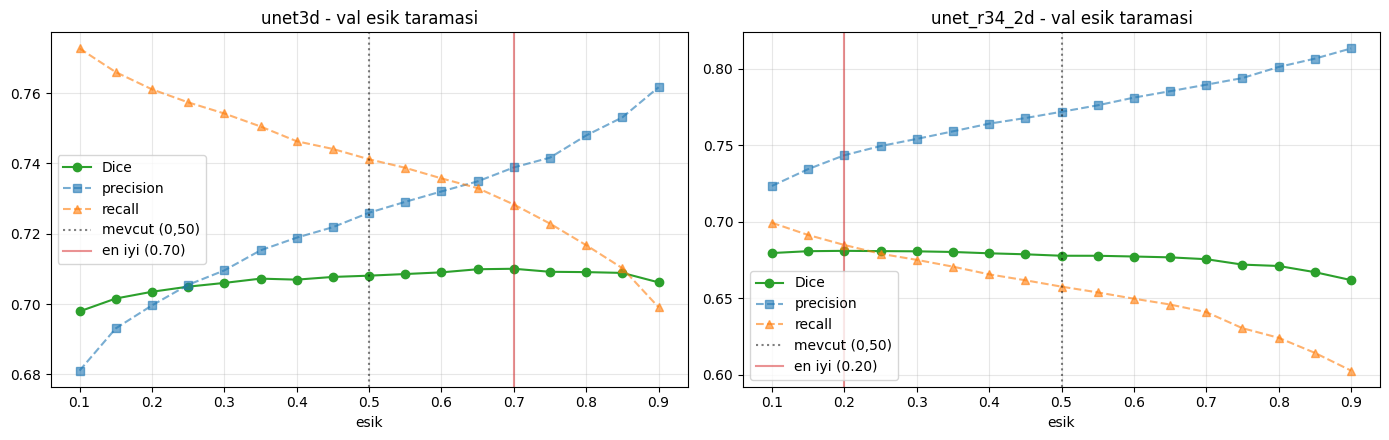

In [11]:
fig, ax = plt.subplots(1, len(ADAYLAR), figsize=(7 * len(ADAYLAR), 4.5))
ax = np.atleast_1d(ax)
for i, mk in enumerate(ADAYLAR):
    d = esik_tablo[mk]
    a = ax[i]
    a.plot(d.esik, d.dice, 'o-', label='Dice', color='tab:green')
    a.plot(d.esik, d.precision, 's--', label='precision', alpha=.6)
    a.plot(d.esik, d.recall, '^--', label='recall', alpha=.6)
    a.axvline(0.5, color='k', ls=':', alpha=.5, label='mevcut (0,50)')
    e_iyi = d.loc[d.dice.idxmax(), 'esik']
    a.axvline(e_iyi, color='tab:red', ls='-', alpha=.5, label=f'en iyi ({e_iyi:.2f})')
    a.set_title(f'{mk} - val esik taramasi'); a.set_xlabel('esik'); a.grid(alpha=.3); a.legend()
plt.tight_layout()
plt.savefig(os.path.join(DEG_DIR, 'esik_taramasi.png'), dpi=130, bbox_inches='tight')
plt.show()

## 7.2 Kucuk bilesen eleme - **val uzerinde**

In [12]:
MIN_VOXELLER = [0, 5, 10, 20, 50]
SECIM = {}
bilesen_tablo = {}
for mk in ADAYLAR:
    e_iyi = float(esik_tablo[mk].loc[esik_tablo[mk].dice.idxmax(), 'esik'])
    d = pd.concat([tara(mk, 'val', [e_iyi], mv) for mv in MIN_VOXELLER], ignore_index=True)
    bilesen_tablo[mk] = d
    en_iyi = d.loc[d.dice.idxmax()]
    SECIM[mk] = dict(esik=e_iyi, min_voxel=int(en_iyi.min_voxel))
    print(f"\n--- {mk} (val, esik={e_iyi:.2f}) ---")
    print(d[['min_voxel', 'dice', 'precision', 'recall', 'avd_ml', 'lezyon_f1']]
          .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
    print(f"secim: esik={e_iyi:.2f}, min_voxel={int(en_iyi.min_voxel)}")

with open(os.path.join(DEG_DIR, 'secim.json'), 'w') as f:
    json.dump(SECIM, f, indent=2)
print('\nsecim.json yazildi:', SECIM)


--- unet3d (val, esik=0.70) ---
 min_voxel   dice  precision  recall  avd_ml  lezyon_f1
         0 0.7100     0.7389  0.7283  5.9881     0.6306
         5 0.7099     0.7366  0.7273  5.9766     0.6299
        10 0.7094     0.7369  0.7257  5.9674     0.6058
        20 0.7002     0.7063  0.7171  5.9756     0.5329
        50 0.6711     0.6914  0.6755  5.9633     0.4332
secim: esik=0.70, min_voxel=0

--- unet_r34_2d (val, esik=0.20) ---
 min_voxel   dice  precision  recall  avd_ml  lezyon_f1
         0 0.6809     0.7434  0.6847  6.4285     0.4947
         5 0.6756     0.7443  0.6721  6.4392     0.5552
        10 0.6748     0.7501  0.6685  6.4677     0.5382
        20 0.6762     0.7635  0.6625  6.4745     0.5189
        50 0.6301     0.7137  0.6076  6.6018     0.4199
secim: esik=0.20, min_voxel=0

secim.json yazildi: {'unet3d': {'esik': 0.7, 'min_voxel': 0}, 'unet_r34_2d': {'esik': 0.2, 'min_voxel': 0}}


## 7.3 Secimin test'e uygulanmasi

In [13]:
satir = []
test_vaka_m = {}
for mk in ADAYLAR:
    s = SECIM[mk]
    for ad, e, mv in [('once (0,50 / 0)', 0.5, 0), (f"sonra ({s['esik']:.2f} / {s['min_voxel']})",
                                                    s['esik'], s['min_voxel'])]:
        m = []
        for v in SPLIT['test']:
            tah = OLASILIK[(mk, 'test')][v].astype(np.float32) >= e
            if mv:
                tah = bilesen_ele(tah, mv)
            m.append(dict(vaka=v, **vaka_metrikleri(tah, GT['test'][v])))
        o = topla(m)
        satir.append(dict(model=mk, ayar=ad, **{k: o[k] for k in
                     ('dice', 'iou', 'precision', 'recall', 'hd95', 'avd_ml', 'lezyon_f1')}))
        if ad.startswith('sonra'):
            test_vaka_m[mk] = pd.DataFrame(m)

son = pd.DataFrame(satir)
print(son.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
son.to_excel(os.path.join(DEG_DIR, 'esik_bilesen_etkisi.xlsx'), index=False)

      model             ayar   dice    iou  precision  recall    hd95  avd_ml  lezyon_f1
     unet3d  once (0,50 / 0) 0.7023 0.5787     0.6886  0.7562 16.5821  3.7646     0.5698
     unet3d sonra (0.70 / 0) 0.7063 0.5835     0.7098  0.7421 15.8338  3.2302     0.5811
unet_r34_2d  once (0,50 / 0) 0.6965 0.5616     0.7540  0.6844 16.0582  2.8406     0.5717
unet_r34_2d sonra (0.20 / 0) 0.6957 0.5606     0.7203  0.7122 17.7509  2.8086     0.5497


## 7.4 Bootstrap guven araliklari + Holm

In [14]:
B = 10000
rng_b = np.random.default_rng(42)

vaka_dice = {}
for mk in BITENLER:
    d = pd.read_excel(os.path.join(PROJE, mk, f'{mk}_test_tahminler.xlsx'))
    vaka_dice[mk] = d.set_index('vaka').dice.reindex(SPLIT['test']).values

n = len(SPLIT['test'])
idx = rng_b.integers(0, n, size=(B, n))          # tum modellerde AYNI indeksler -> eslestirilmis

def ci(dizi):
    orn = dizi[idx].mean(axis=1)
    return np.percentile(orn, [2.5, 97.5])

satir = []
taban_d = vaka_dice[TABAN]
for mk in BITENLER:
    d = vaka_dice[mk]
    lo, hi = ci(d)
    if mk == TABAN:
        fark_lo = fark_hi = np.nan
        p = np.nan
    else:
        fark = (d - taban_d)
        fark_lo, fark_hi = ci(fark)
        p = stats.wilcoxon(d, taban_d).pvalue
    satir.append(dict(model=mk, dice=d.mean(), ci_alt=lo, ci_ust=hi,
                      fark=np.nan if mk == TABAN else float((d - taban_d).mean()),
                      fark_ci_alt=fark_lo, fark_ci_ust=fark_hi, wilcoxon_p=p))

boot = pd.DataFrame(satir).sort_values('dice', ascending=False)

# Holm duzeltmesi
kars = boot[boot.model != TABAN].sort_values('wilcoxon_p').reset_index(drop=True)
m_k = len(kars)
red = True
holm = []
for i, r in kars.iterrows():
    esik = 0.05 / (m_k - i)
    if red and r.wilcoxon_p < esik:
        holm.append('ANLAMLI')
    else:
        red = False
        holm.append('anlamli degil')
kars['holm_esik'] = [0.05 / (m_k - i) for i in range(m_k)]
kars['holm'] = holm
boot = boot.merge(kars[['model', 'holm_esik', 'holm']], on='model', how='left')

print(boot.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
boot.to_excel(os.path.join(DEG_DIR, 'bootstrap_ci.xlsx'), index=False)

       model   dice  ci_alt  ci_ust    fark  fark_ci_alt  fark_ci_ust  wilcoxon_p  holm_esik          holm
      unet3d 0.7023  0.6338  0.7609  0.0058      -0.0400       0.0458      0.0844     0.0167 anlamli degil
 unet_r34_2d 0.6965  0.6402  0.7453     NaN          NaN          NaN         NaN        NaN           NaN
       A3_k1 0.6896  0.6284  0.7428 -0.0069      -0.0336       0.0183      0.6652     0.0500 anlamli degil
  A2_tversky 0.6806  0.6188  0.7340 -0.0159      -0.0477       0.0140      0.1714     0.0250 anlamli degil
       A3_k3 0.6796  0.6205  0.7328 -0.0169      -0.0380       0.0031      0.0844     0.0125 anlamli degil
   unet_mbv3 0.6744  0.6139  0.7294 -0.0221      -0.0512       0.0060      0.0048     0.0083       ANLAMLI
unet_r34_25d 0.6652  0.5974  0.7242 -0.0313      -0.0657      -0.0024      0.0249     0.0100 anlamli degil
    A1_flair 0.6568  0.5889  0.7182 -0.0397      -0.0795      -0.0038      0.0011     0.0071       ANLAMLI
segformer_b0 0.6398  0.5765  0.6964 -

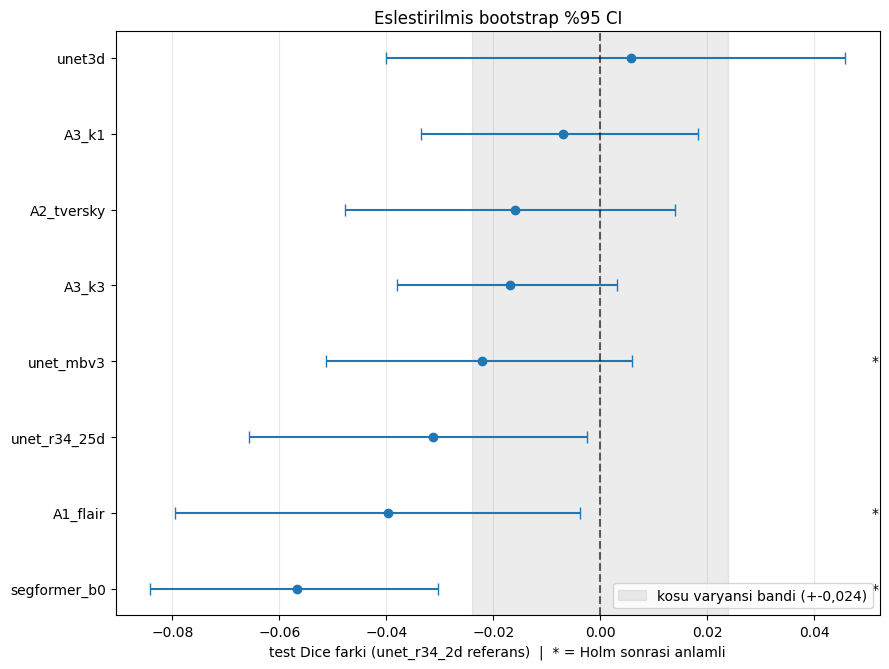

In [15]:
# Forest plot: taban cizgisine gore fark + %95 CI
k = boot[boot.model != TABAN].sort_values('fark')
fig, a = plt.subplots(figsize=(9, 0.6 * len(k) + 2))
y = np.arange(len(k))
a.errorbar(k.fark, y, xerr=[k.fark - k.fark_ci_alt, k.fark_ci_ust - k.fark], fmt='o',
           capsize=4, color='tab:blue')
a.axvline(0, color='k', ls='--', alpha=.6)
a.axvspan(-0.024, 0.024, color='gray', alpha=.15, label='kosu varyansi bandi (+-0,024)')
a.set_yticks(y); a.set_yticklabels(k.model)
for i, (_, r) in enumerate(k.iterrows()):
    a.text(k.fark_ci_ust.max() + 0.005, i, ('*' if r.holm == 'ANLAMLI' else ''), va='center')
a.set_xlabel(f'test Dice farki ({TABAN} referans)  |  * = Holm sonrasi anlamli')
a.set_title('Eslestirilmis bootstrap %95 CI'); a.grid(alpha=.3, axis='x'); a.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(DEG_DIR, 'forest_dice.png'), dpi=130, bbox_inches='tight')
plt.show()

## 7.5 Lezyon F1 tanim dogrulamasi

In [16]:
IOU_ESIKLER = [0.0001, 0.1, 0.25, 0.5]
mk = ADAYLAR[0]
s = SECIM[mk]
duyarlilik = []
for ie in IOU_ESIKLER:
    v_ = []
    for v in SPLIT['test']:
        tah = OLASILIK[(mk, 'test')][v].astype(np.float32) >= s['esik']
        if s['min_voxel']:
            tah = bilesen_ele(tah, s['min_voxel'])
        v_.append(lezyon_metrikleri(tah, GT['test'][v], iou_esik=ie)['lezyon_f1'])
    duyarlilik.append(dict(iou_esik=ie, lezyon_f1=float(np.mean(v_))))
duy = pd.DataFrame(duyarlilik)
print(f'--- {mk}: lezyon F1 - IoU esigine duyarlilik ---')
print(duy.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\naralik: {duy.lezyon_f1.max() - duy.lezyon_f1.min():.4f}')

--- unet3d: lezyon F1 - IoU esigine duyarlilik ---
 iou_esik  lezyon_f1
   0.0001     0.6088
   0.1000     0.5811
   0.2500     0.5274
   0.5000     0.3994

aralik: 0.2094


In [17]:
PANOPTICA_OK = False
try:
    os.system('pip -q install panoptica')
    from panoptica import Panoptica_Evaluator, InputType
    # UNMATCHED_INSTANCE girdisi bir eslestirme algoritmasi ISTIYOR; verilmezse
    # "Got UnmatchedInstancePair but not InstanceMatchingAlgorithm" hatasi geliyor.
    # Esik bizim uygulamamizla ayni (0,1) olmali, yoksa karsilastirma anlamsiz.
    try:
        from panoptica.instance_matcher import NaiveThresholdMatching
    except ImportError:
        from panoptica import NaiveThresholdMatching
    ev = Panoptica_Evaluator(expected_input=InputType.UNMATCHED_INSTANCE,
                             instance_matcher=NaiveThresholdMatching(
                                 matching_threshold=LEZYON_IOU_ESIK))
    pan = []
    for v in SPLIT['test'][:10]:                    # 10 vaka - panoptica yavas
        tah = OLASILIK[(mk, 'test')][v].astype(np.float32) >= s['esik']
        if s['min_voxel']:
            tah = bilesen_ele(tah, s['min_voxel'])
        et_t = ndimage.label(tah, BAGLANTI)[0]
        et_g = ndimage.label(GT['test'][v], BAGLANTI)[0]
        r = ev.evaluate(et_t, et_g)['ungrouped']
        # panoptica'nin RQ'su (recognition quality) bizim lezyon F1'imizle ayni tanim:
        # 2TP / (2TP + FP + FN) bilesen duzeyinde.
        pan.append(dict(vaka=v, panoptica_rq=float(r.rq),
                        bizim=lezyon_metrikleri(tah, GT['test'][v])['lezyon_f1']))
    pn = pd.DataFrame(pan)
    korelasyon = pn.panoptica_rq.corr(pn.bizim)
    print(pn.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
    print(f'\nortalama: panoptica {pn.panoptica_rq.mean():.4f} | bizim {pn.bizim.mean():.4f}'
          f' | korelasyon {korelasyon:.3f}')
    pn.to_excel(os.path.join(DEG_DIR, 'panoptica_karsilastirma.xlsx'), index=False)
    PANOPTICA_OK = True
except Exception as e:
    print('panoptica DOGRULAMASI YAPILAMADI:', repr(e)[:200])
    print('-> Rapora "lezyon F1 kendi uygulamamizla, panoptica ile capraz dogrulanmadi" yazilacak.')

────────────────────────────────────────── Thank you for using panoptica ──────────────────────────────────────────

Please support our development by citing

https://github.com/BrainLesion/panoptica#citation -- Thank you!

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

              vaka  panoptica_rq  bizim
sub-strokecase0001        0.6939 0.6939
sub-strokecase0004        0.7143 0.7143
sub-strokecase0007        0.0000 0.0000
sub-strokecase0008        0.6000 0.6000
sub-strokecase0010        0.5217 0.5217
sub-strokecase0016        0.0000 0.0000
sub-strokecase0020        0.8571 0.8571
sub-strokecase0022        1.0000 1.0000
sub-strokecase0029        0.6667 0.6667
sub-strokecase0031        0.4242 0.4242

ortalama: panoptica 0.5478 | bizim 0.5478 | korelasyon 1.000


In [18]:
ozet7 = dict(
    secim=SECIM,
    esik_val_kazanc={mk: float(esik_tablo[mk].dice.max() -
                               esik_tablo[mk][esik_tablo[mk].esik == 0.5].dice.iloc[0])
                     for mk in ADAYLAR},
    holm_anlamli=boot[boot.holm == 'ANLAMLI'].model.tolist(),
    en_iyi_test_dice=boot.iloc[0][['model', 'dice', 'ci_alt', 'ci_ust']].to_dict(),
    lezyon_f1_iou_duyarlilik=float(duy.lezyon_f1.max() - duy.lezyon_f1.min()),
    panoptica_dogrulandi=PANOPTICA_OK,
    kosu_varyans_bandi=0.024,
)
print(json.dumps(ozet7, indent=2, ensure_ascii=False, default=str))
with open(os.path.join(DEG_DIR, 'degerlendirme_ozeti.json'), 'w', encoding='utf-8') as f:
    json.dump(ozet7, f, indent=2, ensure_ascii=False, default=str)
for mk, d in test_vaka_m.items():
    d.to_excel(os.path.join(DEG_DIR, f'{mk}_test_secimli.xlsx'), index=False)
print('\nyazildi:', DEG_DIR)
for q in sorted(os.listdir(DEG_DIR)):
    print('  ', q)
print('\nPARCA 7 TAMAM.')

{
  "secim": {
    "unet3d": {
      "esik": 0.7,
      "min_voxel": 0
    },
    "unet_r34_2d": {
      "esik": 0.2,
      "min_voxel": 0
    }
  },
  "esik_val_kazanc": {
    "unet3d": 0.001968786985581339,
    "unet_r34_2d": 0.0032038472722016875
  },
  "holm_anlamli": [
    "unet_mbv3",
    "A1_flair",
    "segformer_b0"
  ],
  "en_iyi_test_dice": {
    "model": "unet3d",
    "dice": 0.7023322640479095,
    "ci_alt": 0.6337640366509997,
    "ci_ust": 0.7609121217818993
  },
  "lezyon_f1_iou_duyarlilik": 0.2093692344240552,
  "panoptica_dogrulandi": true,
  "kosu_varyans_bandi": 0.024
}

yazildi: /content/drive/MyDrive/iskemik_inme/degerlendirme
   bootstrap_ci.xlsx
   degerlendirme_ozeti.json
   esik_bilesen_etkisi.xlsx
   esik_taramasi.png
   forest_dice.png
   panoptica_karsilastirma.xlsx
   secim.json
   unet3d_test_secimli.xlsx
   unet_r34_2d_test_secimli.xlsx

PARCA 7 TAMAM.
